# K-Means Clustering

K-Means is an unsupervised learning algorithm used to divide observations into a predefined number of clusters.

The algorithm groups observations based on their similarity.

### Main Steps

1. Load the dataset
2. Select useful features
3. Handle missing values
4. Scale the features
5. Choose the number of clusters (K)
6. Train the K-Means model
7. Assign cluster labels
8. Visualize the clusters
9. Evaluate the clustering

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("penguins")

# Display first rows
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
df.shape

(344, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].copy()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


In [7]:
X.isnull().sum()

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [8]:
# Remove rows containing missing values
X = X.dropna()

print("Shape after removing missing values:", X.shape)

Shape after removing missing values: (342, 4)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)","[[ 0.

In [11]:
cluster_labels = kmeans.labels_

cluster_labels[:20]

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2],
      dtype=int32)

In [12]:
clustered_data = X.copy()

clustered_data["Cluster"] = cluster_labels

clustered_data.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,2
2,40.3,18.0,195.0,3250.0,2
4,36.7,19.3,193.0,3450.0,2
5,39.3,20.6,190.0,3650.0,2


In [13]:
clustered_data["Cluster"].value_counts().sort_index()

Cluster
0     87
1    123
2    132
Name: count, dtype: int64

In [14]:
centroids = kmeans.cluster_centers_

centroids

array([[ 0.66097295,  0.8169259 , -0.28620559, -0.37431308],
       [ 0.65722922, -1.09998045,  1.15886506,  1.0917612 ],
       [-1.04805941,  0.48655336, -0.89121603, -0.77061658]])

In [15]:
centroids_original = scaler.inverse_transform(
    centroids
)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)

centroids_df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,47.525287,18.762069,196.896552,3902.011494
1,47.504878,14.982114,217.186992,5076.016260
2,38.208333,18.110606,188.401515,3584.659091


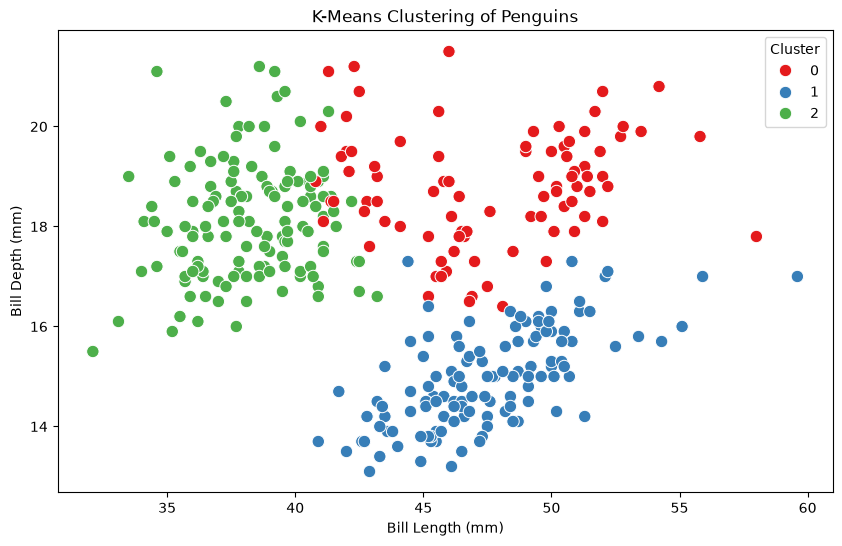

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clustered_data,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("K-Means Clustering of Penguins")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")

plt.show()

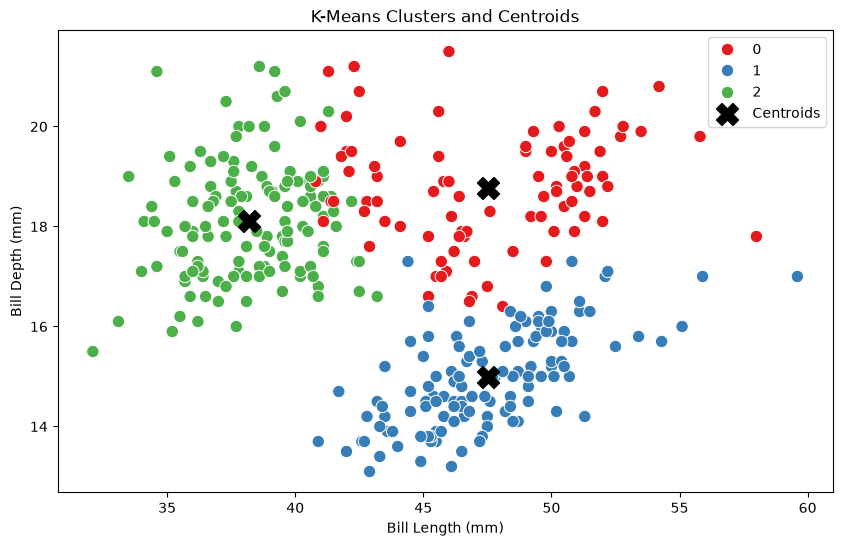

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clustered_data,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.scatter(
    centroids_df["bill_length_mm"],
    centroids_df["bill_depth_mm"],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.title("K-Means Clusters and Centroids")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")

plt.legend()

plt.show()

# Elbow Method

One of the most common methods for selecting the number of clusters is the **Elbow Method**.

We train K-Means using different values of K and calculate the inertia.

### Inertia

Inertia measures the total squared distance between observations and their nearest cluster centroid.

$$
Inertia =
\sum_{i=1}^{n}
||x_i-\mu_{c_i}||^2
$$

Lower inertia is generally better.

However, increasing K will almost always decrease inertia.

Therefore, we look for an **elbow point**, where increasing K further provides relatively little improvement.

In [18]:
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

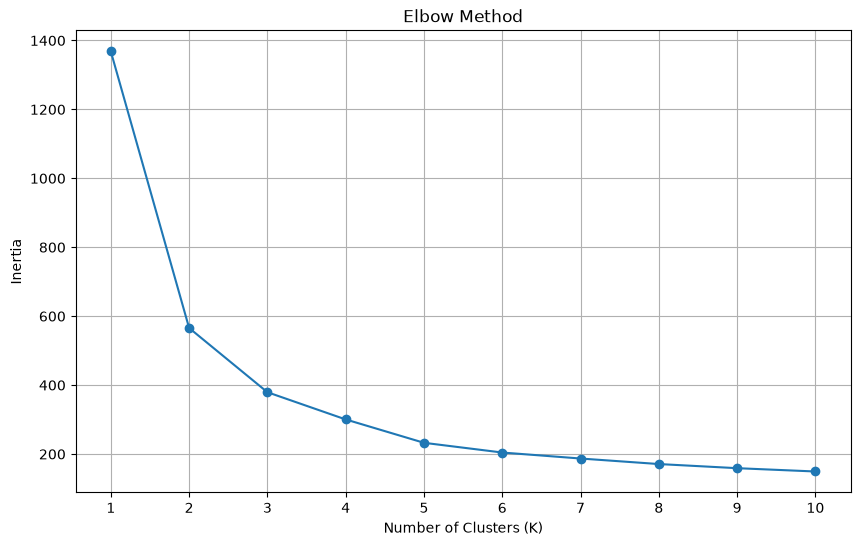

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.grid()

plt.show()

# Silhouette Score

The Silhouette Score measures how well each observation fits within its assigned cluster compared with other clusters.

The score ranges approximately from:

$$
-1 \leq Silhouette\ Score \leq 1
$$

### Interpretation

| Score | Interpretation |
|---:|---|
| Close to 1 | Well-separated clusters |
| Around 0 | Overlapping clusters |
| Negative | Possible incorrect clustering |

Higher Silhouette Score generally indicates better-defined clusters.

In [20]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Silhouette Score:",
    silhouette
)

Silhouette Score: 0.4472192983966046


In [21]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.5315
K = 3, Silhouette Score = 0.4472
K = 4, Silhouette Score = 0.3996
K = 5, Silhouette Score = 0.3789
K = 6, Silhouette Score = 0.3680
K = 7, Silhouette Score = 0.3309
K = 8, Silhouette Score = 0.2961
K = 9, Silhouette Score = 0.2834
K = 10, Silhouette Score = 0.2846


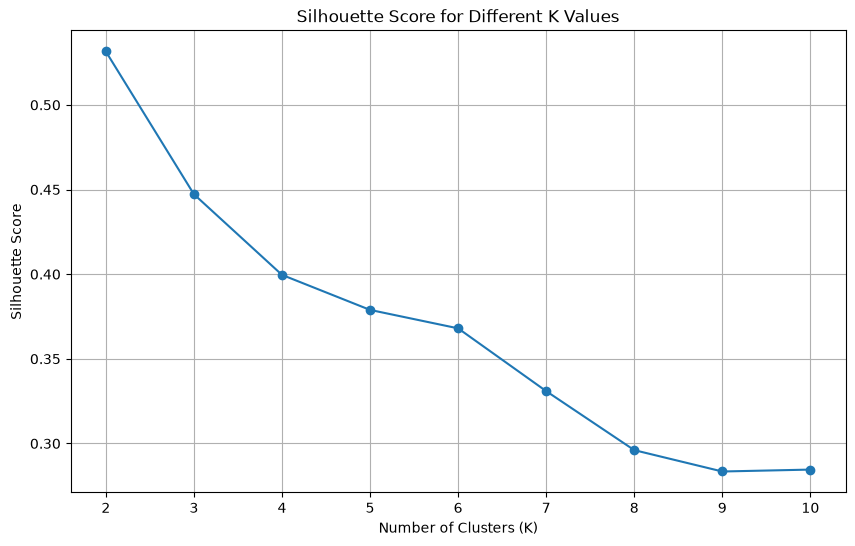

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid()

plt.show()

# Final K-Means Model

After examining the Elbow Method and Silhouette Score, choose a reasonable value of K.

For this example, we will continue with:

```text
K = 3

In [23]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(
    X_scaled
)

In [24]:
final_data = X.copy()

final_data["Cluster"] = final_labels

final_data.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,2
2,40.3,18.0,195.0,3250.0,2
4,36.7,19.3,193.0,3450.0,2
5,39.3,20.6,190.0,3650.0,2
6,38.9,17.8,181.0,3625.0,2
7,39.2,19.6,195.0,4675.0,2
8,34.1,18.1,193.0,3475.0,2
9,42.0,20.2,190.0,4250.0,0
10,37.8,17.1,186.0,3300.0,2


In [25]:
final_data["Cluster"].value_counts().sort_index()

Cluster
0     87
1    123
2    132
Name: count, dtype: int64

In [26]:
cluster_summary = final_data.groupby(
    "Cluster"
)[features].mean()

cluster_summary

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster,,,,
0,47.525287,18.762069,196.896552,3902.011494
1,47.504878,14.982114,217.186992,5076.016260
2,38.208333,18.110606,188.401515,3584.659091


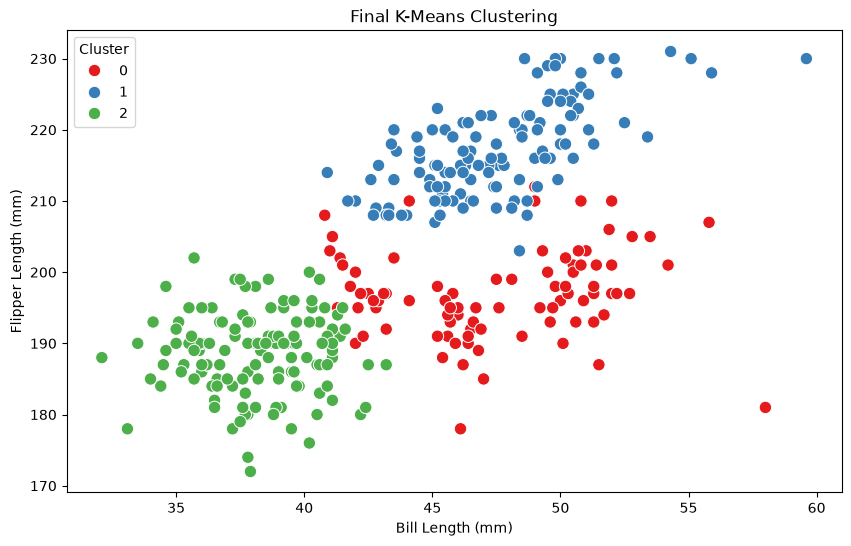

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_data,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Final K-Means Clustering")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")

plt.show()